# Домашнее задание 1

**Студент:** Мерзляков Арсений Денисович

**Группа:** Б01-303


###### Требования к выполнению

Сдайте один файл `.ipynb` с кодом, результатами выполнения и обоснованными ответами.
<div style="color: #d00000; font-size: 16px; font-weight: 800; line-height: 1.3; margin-bottom: 24px;">ВНИМАНИЕ!<br>ПОСЛЕ ЗАГРУЗКИ НОУТБУКА В БОТА ЕГО НЕЛЬЗЯ ИЗМЕНЯТЬ ИЛИ ПЕРЕЗАПУСКАТЬ.</div>

Используйте предоставленные разбиения данных. Модели и преобразования обучайте
только на train, гиперпараметры выбирайте по validation. Test используйте
для финальной оценки после фиксации модели и её настроек; изменять решение
по результатам test нельзя. Перед оценкой на test не переобучайте модель
на train + validation.

## Зависимости

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown

SEED = 42
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 130)
pd.set_option("display.precision", 4)
sklearn.set_config(display="text")
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | "
      f"pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"matplotlib {matplotlib.__version__}")

Python 3.10.13 | NumPy 2.2.6 | pandas 2.3.3 | scikit-learn 1.7.2 | matplotlib 3.10.9


## Задача 1. Регуляризация линейной регрессии

Признаки и целевая переменная центрированы. Пусть $X\in\mathbb{R}^{n\times d}$ и

$$\frac{X^\top X}{n}=I_d,\qquad \frac{X^\top y}{n}=c.$$

При $\lambda>0$ заданы функции:

$$L_{\mathrm{OLS}}(w)=\frac{1}{2n}\|y-Xw\|_2^2,$$
$$L_{\mathrm{Ridge}}(w)=\frac{1}{2n}\|y-Xw\|_2^2+\frac{\lambda}{2}\|w\|_2^2,$$
$$L_{\mathrm{Lasso}}(w)=\frac{1}{2n}\|y-Xw\|_2^2+\lambda\|w\|_1.$$

1. Найдите и обоснуйте решения всех трёх задач минимизации.
2. В этом пункте условие $X^\top X/n=I_d$ не предполагается. Для произвольной фиксированной матрицы центрированных признаков докажите, что с ростом $\lambda>0$ евклидова норма оптимального вектора коэффициентов Ridge не возрастает, а обучающая ошибка $\|y-X\hat w_\lambda\|_2^2$ не убывает.
3. Столбец $X_j$ умножили на $a=10$, остальные столбцы не меняли. Как изменить коэффициент, чтобы сохранить предсказания? Как изменятся штрафы для того же предсказания? Сохранится ли оптимальное предсказание OLS? Объясните связь этого преобразования со стандартизацией признаков.
4. Если добавить свободный член $b$, следует ли включать его в штраф? Обоснуйте ответ.

### 1.1
Раскроем $L_{OLS}$:
$$\frac{1}{2n}\|y-Xw\|_2^2=\frac{\|y\|_2^2}{2n}-c^\top w+\frac12\|w\|_2^2
=\mathrm{const}+\frac12\|w-c\|_2^2.$$

* **OLS:** минимум достигается при $\boxed{\hat w^{OLS}=c}$.
* **Ridge:** градиент равен $(1+\lambda)w-c$, поэтому $\boxed{\hat w^{Ridge}=c/(1+\lambda)}$.
* **Lasso:** здесь для  каждой координаты нужен $\min_{w_j}\{\frac12(w_j-c_j)^2+\lambda|w_j|\}$. При $w_j>0$ производная $w_j-c_j+\lambda=0$, при $w_j<0$ — $w_j-c_j-\lambda=0$; в нуле условие субградиента $0\in-c_j+\lambda[-1,1]$. Отсюда
$$\boxed{\hat w_j^{Lasso}=\operatorname{sign}(c_j)\max(|c_j|-\lambda,0).}$$


### 1.2
Пусть $f(w)=\|y-Xw\|_2^2/(2n)$, $g(w)=\|w\|_2^2/2$ и возьмём $0<\lambda_1<\lambda_2$. Пусть $w_1,w_2$ минимизируют $f+\lambda_1g$ и $f+\lambda_2g$ соответственно. Из оптимальности получаем
$$f(w_1)+\lambda_1g(w_1)\le f(w_2)+\lambda_1g(w_2),$$
$$f(w_2)+\lambda_2g(w_2)\le f(w_1)+\lambda_2g(w_1).$$
Складываем: $(\lambda_2-\lambda_1)(g(w_2)-g(w_1))\le0$, значит $\|w_2\|_2\le\|w_1\|_2$. Из первого неравенства
$$f(w_1)-f(w_2)\le \lambda_1(g(w_2)-g(w_1))\le0.$$
Следовательно, $\|y-Xw_1\|_2^2\le\|y-Xw_2\|_2^2$.


### 1.3
Пусть $X'_j=aX_j$ при $a=10$. Чтобы сохранить линейный прогноз для каждого объекта, надо взять $w'_j=w_j/a$, остальные коэффициенты и свободный член оставить без изменений: $X'_jw'_j=X_jw_j$. Для того же прогноза вклад этой координаты в штраф в Ridge изменится с $\lambda w_j^2/2$ до $\lambda w_j^2/(2a^2)$ (то есть в 100 раз уменьшится), а в Lasso — с $\lambda|w_j|$ до $\lambda|w_j|/a$ (то есть в 10 раз уменьшится); остальные слагаемые не изменятся.

OLS минимизирует только остатки, а множество достижимых прогнозов после такого обратимого масштабирования не меняется. Поэтому оптимальный OLS-прогноз на обучающих объектах сохранится. У Ridge и Lasso изменились штрафы, поэтому их оптимальные прогнозы могут измениться. Стандартизация приводит признаки к сопоставимым масштабам до применения штрафа и устраняет именно эту зависимость от единиц измерения (то есть чтобы разные веса штрафовались сопоставимо). 


### 1.4
Обычно свободный член $b$ не штрафуется. Он задаёт общий уровень предсказания (просто некий сдвиг), а не чувствительность к изменениям признаков: штрафование $b$ искусственно тянуло бы средний прогноз к нулю и делало результат зависимым от сдвига целевой переменной на константу. При фиксированном $w$ и квадратичной ошибке без штрафа оптимален $b=\bar y-\bar X^\top w$; при центрированных $X$ и $y$ это $b=0$.


## Задача 2. Метрики классификации и порог решения

Положительный класс — $y=1$. Для объектов заданы оценки вероятности $p(x)\in[0,1]$.
Правило классификации: $\hat y=1$, если $p(x)\geq t$, иначе $\hat y=0$.

1. На фиксированной конечной выборке, содержащей оба класса, исследуйте монотонность recall, precision и accuracy как функций порога $t$. Утверждения обоснуйте доказательствами или контрпримерами. Precision рассматривайте при наличии положительных предсказаний.
2. Стоимость верного решения равна 0, ложноположительного — $c_{FP}>0$, ложноотрицательного — $c_{FN}>0$. В этом пункте считайте $p(x)=P(y=1\mid x)$ истинной условной вероятностью. Выведите порог, минимизирующий ожидаемую стоимость ошибки. Обязан ли он минимизировать фактическую стоимость ошибок на любой конечной выборке? Докажите утверждение или приведите контрпример.
3. Пусть $p(x)=\sigma(w^\top x+b)$, где $\sigma(z)=1/(1+e^{-z})$. Какой порог на $z=w^\top x+b$ соответствует порогу $0<t<1$? При каких условиях порог из пункта 2 применим к прогнозам обученной модели?

### 2.1
Когда $t$ растёт, множество предсказанных единиц $\{i:p_i\ge t\}$ может только сужаться. Значит, число TP и $\mathrm{recall}=TP/(TP+FN)$ не возрастают (знаменатель — фиксированное число реальных единиц).

Precision $TP/(TP+FP)$ не монотонна, поскольку новый порог может отсеять как ложноположительный, так и истинноположительный объект. Контрпример: три объекта с $(p,y)=(0.9,1),(0.8,0),(0.7,1)$. При $t=0.7,0.8,0.9$ precision равна соответственно $2/3,1/2,1$ — сперва падает, потом растёт; положительные предсказания есть везде.

Accuracy $(TP+TN)/n$ также не монотонна: в том же примере она равна $2/3,1/3,2/3$. Отсеивание положительного примера понижает accuracy, отрицательного — повышает.


### 2.2
Для объекта с истинной условной вероятностью $p=P(y=1\mid x)$ стоимость ошибки равна
$$R(\hat y=1\mid x)=c_{FP}(1-p),\qquad R(\hat y=0\mid x)=c_{FN}p.$$
Предсказываем единицу, когда $c_{FP}(1-p)\le c_{FN}p$, то есть при
$$\boxed{t^*=\frac{c_{FP}}{c_{FP}+c_{FN}}.}$$
При равенстве стоимости решений одинаковы; правило $p\ge t^*$ выбирает единицу. Это минимизирует математическое ожидание ошибки, а не гарантированный минимум по каждой реализовавшейся выборке. Например, при $c_{FP}=c_{FN}=1$ и двух объектах $(p,y)=(0.9,0),(0.1,1)$ порог $t^*=0.5$ даёт две ошибки, а $t=1$ — одну.


### 2.3
Сигмоида строго возрастает, поэтому при $0<t<1$
$$p(x)\ge t\quad\Longleftrightarrow\quad w^\top x+b\ge\boxed{\log\frac{t}{1-t}}.$$
Теоретический $t^*$ из 2.2 можно применять к прогнозам обученной модели как правило минимизации ожидаемых затрат, если её вероятности достаточно хорошо калиброваны и приближают $P(y=1\mid x)$ на той же популяции. То есть если выход полученный модели близок к истинной условной вероятности, то t* можно применять.


## Задача 3. Регрессия

Используйте набор данных `Diabetes`: 442 наблюдения, 10 признаков и численный
показатель прогрессирования диабета через год. Признаки: `age` — возраст,
`sex` — пол, `bmi` — индекс массы тела, `bp` — среднее артериальное давление,
`s1`–`s6` — лабораторные показатели.

Рассматриваются OLS — линейная регрессия методом наименьших квадратов,
Ridge — линейная регрессия с L2-регуляризацией и Lasso — с L1-регуляризацией.
В качестве базовой модели используется `DummyRegressor`, предсказывающий
среднее значение целевой переменной на обучающей выборке.

Данные загружаются с `scaled=False`. Разбиение train / validation / test —
приблизительно 60 / 20 / 20%. Финальная оценка на test выполняется в пункте 3.5.

[Описание данных](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html).

In [3]:
from IPython.display import Markdown as reg_Markdown
from sklearn.datasets import load_diabetes as reg_load_diabetes
from sklearn.dummy import DummyRegressor as reg_DummyRegressor
from sklearn.linear_model import (
    LinearRegression as reg_LinearRegression,
    Ridge as reg_Ridge,
    Lasso as reg_Lasso,
)
from sklearn.metrics import mean_squared_error as reg_mean_squared_error
from sklearn.model_selection import train_test_split as reg_train_test_split
from sklearn.pipeline import Pipeline as reg_Pipeline
from sklearn.preprocessing import StandardScaler as reg_StandardScaler

reg_dataset = reg_load_diabetes(as_frame=True, scaled=False)
reg_X_train, reg_X_holdout, reg_y_train, reg_y_holdout = reg_train_test_split(
    reg_dataset.data, reg_dataset.target, test_size=0.4, random_state=SEED
)
reg_X_valid, reg_X_test, reg_y_valid, reg_y_test = reg_train_test_split(
    reg_X_holdout, reg_y_holdout, test_size=0.5, random_state=SEED
)
del reg_dataset, reg_X_holdout, reg_y_holdout

def reg_rmse(y_true, y_pred):
    return float(np.sqrt(reg_mean_squared_error(y_true, y_pred)))

print(f"Train: {len(reg_y_train)}; validation: {len(reg_y_valid)}; "
      f"test: {len(reg_y_test)} наблюдений.")

Train: 265; validation: 88; test: 89 наблюдений.


### 3.1

На train проверьте пропуски, повторяющиеся строки и диапазоны признаков.
Постройте диаграмму `bmi`–`target` и вычислите корреляции между признаками.

1. Сравните численные масштабы признаков.
2. Как интерпретировать числовые значения `sex`? Достаточно ли одного столбца для представления этого признака в линейной модели со свободным членом?
3. Найдите тесно коррелирующую пару признаков. Как такая связь влияет на интерпретацию коэффициентов линейной модели?
4. Можно ли сделать вывод о причинном влиянии `bmi` на ответ? Обоснуйте ответ.

Пропуски в X / y: 0 / 0
Повторяющиеся строки X: 0


,min,max,std,missing
age,19.000,79.000,12.980,0
sex,1.000,2.000,0.499,0
bmi,18.600,41.300,4.450,0
bp,62.000,133.000,13.973,0
s1,110.000,301.000,35.052,0
s2,41.600,242.400,30.615,0
s3,22.000,99.000,13.147,0
s4,2.000,9.090,1.296,0
s5,3.496,6.107,0.525,0
s6,58.000,124.000,11.359,0


Значения признака sex: [np.float64(1.0), np.float64(2.0)]


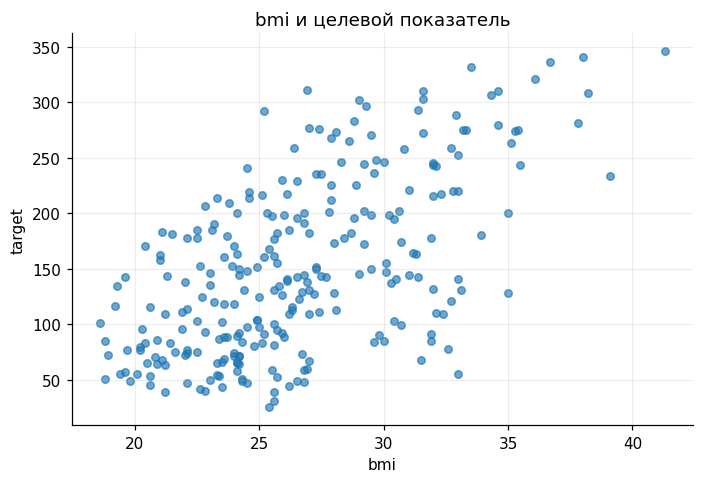

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.00,0.16,0.18,0.33,0.26,0.20,-0.02,0.17,0.28,0.29
sex,0.16,1.00,0.11,0.20,0.03,0.11,-0.33,0.33,0.15,0.17
bmi,0.18,0.11,1.00,0.36,0.25,0.28,-0.41,0.47,0.46,0.42
bp,0.33,0.20,0.36,1.00,0.26,0.18,-0.12,0.23,0.38,0.40
s1,0.26,0.03,0.25,0.26,1.00,0.89,0.07,0.54,0.52,0.33
s2,0.20,0.11,0.28,0.18,0.89,1.00,-0.17,0.65,0.30,0.29
s3,-0.02,-0.33,-0.41,-0.12,0.07,-0.17,1.00,-0.73,-0.38,-0.27
s4,0.17,0.33,0.47,0.23,0.54,0.65,-0.73,1.00,0.63,0.40
s5,0.28,0.15,0.46,0.38,0.52,0.30,-0.38,0.63,1.00,0.47
s6,0.29,0.17,0.42,0.40,0.33,0.29,-0.27,0.40,0.47,1.00


Наибольшая корреляция: ('s1', 's2'), r=0.890
Корреляция bmi с target на train: 0.607


In [10]:
reg_summary = reg_X_train.agg(["min", "max", "std"]).T
reg_summary["missing"] = reg_X_train.isna().sum()
print("Пропуски в X / y:", int(reg_X_train.isna().sum().sum()), "/", int(reg_y_train.isna().sum()))
print("Повторяющиеся строки X:", int(reg_X_train.duplicated().sum()))
display(reg_summary.round(3))
print("Значения признака sex:", sorted(reg_X_train["sex"].unique()))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(reg_X_train["bmi"], reg_y_train, alpha=0.65, s=24)
ax.set(xlabel="bmi", ylabel="target", title="bmi и целевой показатель")
plt.tight_layout()
plt.show()

reg_corr = reg_X_train.corr()
display(reg_corr.round(2))

reg_corr_pairs = reg_corr.where(np.triu(np.ones(reg_corr.shape), k=1).astype(bool)).stack()
reg_strongest = reg_corr_pairs.abs().idxmax()
print(f"Наибольшая корреляция: {reg_strongest}, r={reg_corr_pairs.loc[reg_strongest]:.3f}")
print(f"Корреляция bmi с target на train: {reg_X_train['bmi'].corr(reg_y_train):.3f}")


На train пропусков и повторяющихся строк нет. Масштабы сильно отличаются: `s1` лежит примерно между 110 и 301, а `s5` — между 3.5 и 6.1, поэтому перед Ridge/Lasso признаки стоит стандартизовать. `sex` может быть 1 или 2, то есть признак бинарный, поэтому при наличии свободного члена одного столбца достаточно.

Сильнее всего связаны `s1` и `s2` ($r\approx0.89$): линейной модели трудно однозначно распределять их общий вклад между двумя коэффициентами. На диаграмме `bmi` и ответа есть некая связь, но она не доказывает причинность: возможны другие влияющие переменные, а данные наблюдательные.


### 3.2

Обучите на train `DummyRegressor(strategy="mean")` и `LinearRegression` (OLS).
Для OLS используйте `Pipeline` со `StandardScaler`.
Представьте RMSE обеих моделей на validation в таблице. Сохраните обученные модели.

$$\operatorname{RMSE}=\sqrt{\frac1m\sum_{i=1}^{m}(y_i-\hat y_i)^2}.$$

Интерпретируйте сравнение с Dummy. Объясните, почему среднее для Dummy
и параметры scaler должны вычисляться по train.

In [11]:
reg_dummy = reg_DummyRegressor(strategy="mean").fit(reg_X_train, reg_y_train)
reg_ols = reg_Pipeline([
    ("scaler", reg_StandardScaler()),
    ("model", reg_LinearRegression()),
]).fit(reg_X_train, reg_y_train)
reg_baselines = pd.DataFrame([
    {"Модель": "Dummy", "Validation RMSE": reg_rmse(reg_y_valid, reg_dummy.predict(reg_X_valid))},
    {"Модель": "OLS + StandardScaler", "Validation RMSE": reg_rmse(reg_y_valid, reg_ols.predict(reg_X_valid))},
])
display(reg_baselines.round(3))


,Модель,Validation RMSE
0,Dummy,76.161
1,OLS + StandardScaler,49.150


OLS дала validation RMSE $49.15$ против $76.16$ у Dummy, то есть ожидаемо использовать признаки лучше, чем всем предсказывать одно среднее. Среднее и параметры scaler считаем на train, поскольку иначе информация из validation попадёт в обучение, и проверка перестанет быть независимой.


### 3.3

Создайте копии train и validation, умножив только `bmi` на `1000`.
Сравните четыре варианта:

- OLS без стандартизации;
- OLS со `StandardScaler`;
- `Ridge(alpha=1000)` без стандартизации;
- `Ridge(alpha=1000)` со `StandardScaler`.

Для каждого варианта обучите отдельные модели на исходных и преобразованных
данных. Используйте validation в тех же единицах, что и соответствующий train.

Постройте четыре диаграммы: по горизонтали — прогноз на исходных данных,
по вертикали — прогноз после преобразования для того же объекта.
Добавьте диагональ $y=x$ и одинаковый масштаб осей внутри каждой панели.

1. В каких вариантах изменились прогнозы? Объясните результаты.
2. Как преобразование признака связано с коэффициентом при `bmi` и штрафом Ridge?
3. Какова роль стандартизации в этом эксперименте? Гарантирует ли она снижение ошибки при фиксированном `alpha`?

Ожидание: OLS и Ridge со стандартизацией сохранят прогнозы при пересчёте `bmi`, а Ridge без неё может изменить прогнозы.


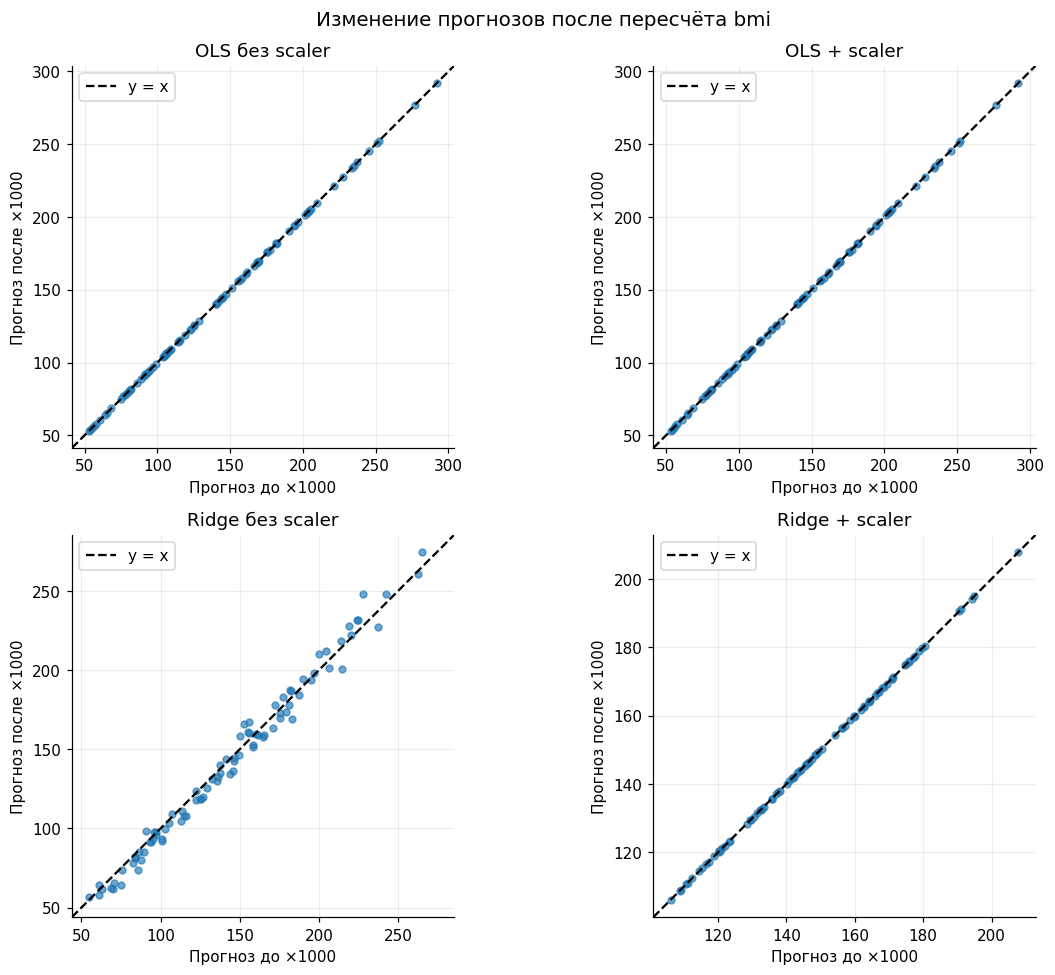

,Модель,Max |изменение прогноза|,RMSE до,RMSE после
0,OLS без scaler,0.0000,49.1497,49.1497
1,OLS + scaler,0.0000,49.1497,49.1497
2,Ridge без scaler,20.0203,52.2432,52.3256
3,Ridge + scaler,0.0000,61.9594,61.9594


In [12]:
reg_X_train_1000 = reg_X_train.copy()
reg_X_valid_1000 = reg_X_valid.copy()
reg_X_train_1000["bmi"] *= 1000
reg_X_valid_1000["bmi"] *= 1000

reg_scale_specs = {
    "OLS без scaler": reg_LinearRegression(),
    "OLS + scaler": reg_Pipeline([("scaler", reg_StandardScaler()), ("model", reg_LinearRegression())]),
    "Ridge без scaler": reg_Ridge(alpha=1000),
    "Ridge + scaler": reg_Pipeline([("scaler", reg_StandardScaler()), ("model", reg_Ridge(alpha=1000))]),
}
from sklearn.base import clone
reg_scale_models = {}
reg_scale_rows = []
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, estimator) in zip(axes.flat, reg_scale_specs.items()):
    original = clone(estimator).fit(reg_X_train, reg_y_train)
    changed = clone(estimator).fit(reg_X_train_1000, reg_y_train)
    reg_scale_models[name] = (original, changed)
    p_original = original.predict(reg_X_valid)
    p_changed = changed.predict(reg_X_valid_1000)
    reg_scale_rows.append({
        "Модель": name,
        "Max |изменение прогноза|": np.max(np.abs(p_original - p_changed)),
        "RMSE до": reg_rmse(reg_y_valid, p_original),
        "RMSE после": reg_rmse(reg_y_valid, p_changed),
    })
    limits = [min(p_original.min(), p_changed.min()), max(p_original.max(), p_changed.max())]
    pad = 0.05 * (limits[1] - limits[0])
    lo, hi = limits[0]-pad, limits[1]+pad
    ax.scatter(p_original, p_changed, s=20, alpha=0.65)
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", label="y = x")
    ax.set(xlim=(lo, hi), ylim=(lo, hi), xlabel="Прогноз до ×1000",
           ylabel="Прогноз после ×1000", title=name)
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
fig.suptitle("Изменение прогнозов после пересчёта bmi", fontsize=13)
fig.tight_layout()
plt.show()
display(pd.DataFrame(reg_scale_rows).round(6))


У обеих OLS и у Ridge со scaler точки легли на диагональ, то есть прогнозы одинаковы с точностью вычислений. У Ridge без scaler максимальная разница прогнозов — около 20, хотя RMSE меняется совсем немного. При умножении `bmi` на 1000 коэффициент для того же прогноза должен уменьшиться в 1000 раз, и его квадрат стал бы штрафоваться в миллион раз слабее. Ridge без scaler поэтому переопределяет оптимальные коэффициенты. Стандартизация не гарантирует меньшую RMSE при том же `alpha`, так как сила штрафа по отношению к данным тоже меняется. Здесь видно RMSE меньше без scaler (нужно `alpha` другое брать при scaler).


### 3.4

На исходных признаках обучите модели в `Pipeline` со `StandardScaler`:

- Ridge: `alpha = [0.1, 1, 10, 100, 1000, 10000]`;
- Lasso: `alpha = [0.01, 0.1, 1, 3, 10, 30, 100]`, `max_iter=20000`.

Для каждого значения сохраните модель, коэффициенты, train RMSE и validation RMSE.
Постройте рисунок из четырёх панелей: в верхнем ряду — зависимости ошибок
от `alpha` для двух моделей, в нижнем — зависимости их коэффициентов от `alpha`.
Используйте логарифмическую ось `alpha` и линию нуля на графиках коэффициентов.

1. Как регуляризация влияет на train RMSE и validation RMSE? Объясните форму полученных кривых.
2. Проверьте по графикам утверждение: «При усилении Ridge-регуляризации каждый коэффициент не возрастает по модулю». Объясните результат и его связь с пунктом 1.2. Сравните поведение с Lasso: есть ли нулевые коэффициенты и что можно заключить о соответствующих признаках?
3. По документации [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) и [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) установите связь `alpha` с $\lambda$ из задачи 1. Можно ли сравнивать силу двух видов регуляризации по одинаковому числу `alpha`?
4. Интерпретируйте знак и величину коэффициента `bmi` у Lasso при `alpha=1`. Можно ли считать модуль коэффициента мерой важности признака? Обоснуйте ответ.

Ожидание: При росте `alpha` train-ошибка не уменьшится, общая норма Ridge снизится, а Lasso начнёт занулять коэффициенты.


,Метод,alpha,Train RMSE,Validation RMSE,||w||_2,Нулевых коэффициентов
0,Ridge,0.10,54.285,49.156,56.892,0
1,Ridge,1.00,54.297,49.203,50.572,0
2,Ridge,10.00,54.395,49.373,41.090,0
3,Ridge,100.00,55.440,50.815,31.935,0
4,Ridge,1000.00,64.442,61.959,13.132,0
5,Ridge,10000.00,74.783,73.407,2.216,0
6,Lasso,0.01,54.285,49.157,56.556,0
7,Lasso,0.10,54.302,49.204,49.263,0
8,Lasso,1.00,54.473,49.525,41.095,2
9,Lasso,3.00,55.022,50.726,37.293,4


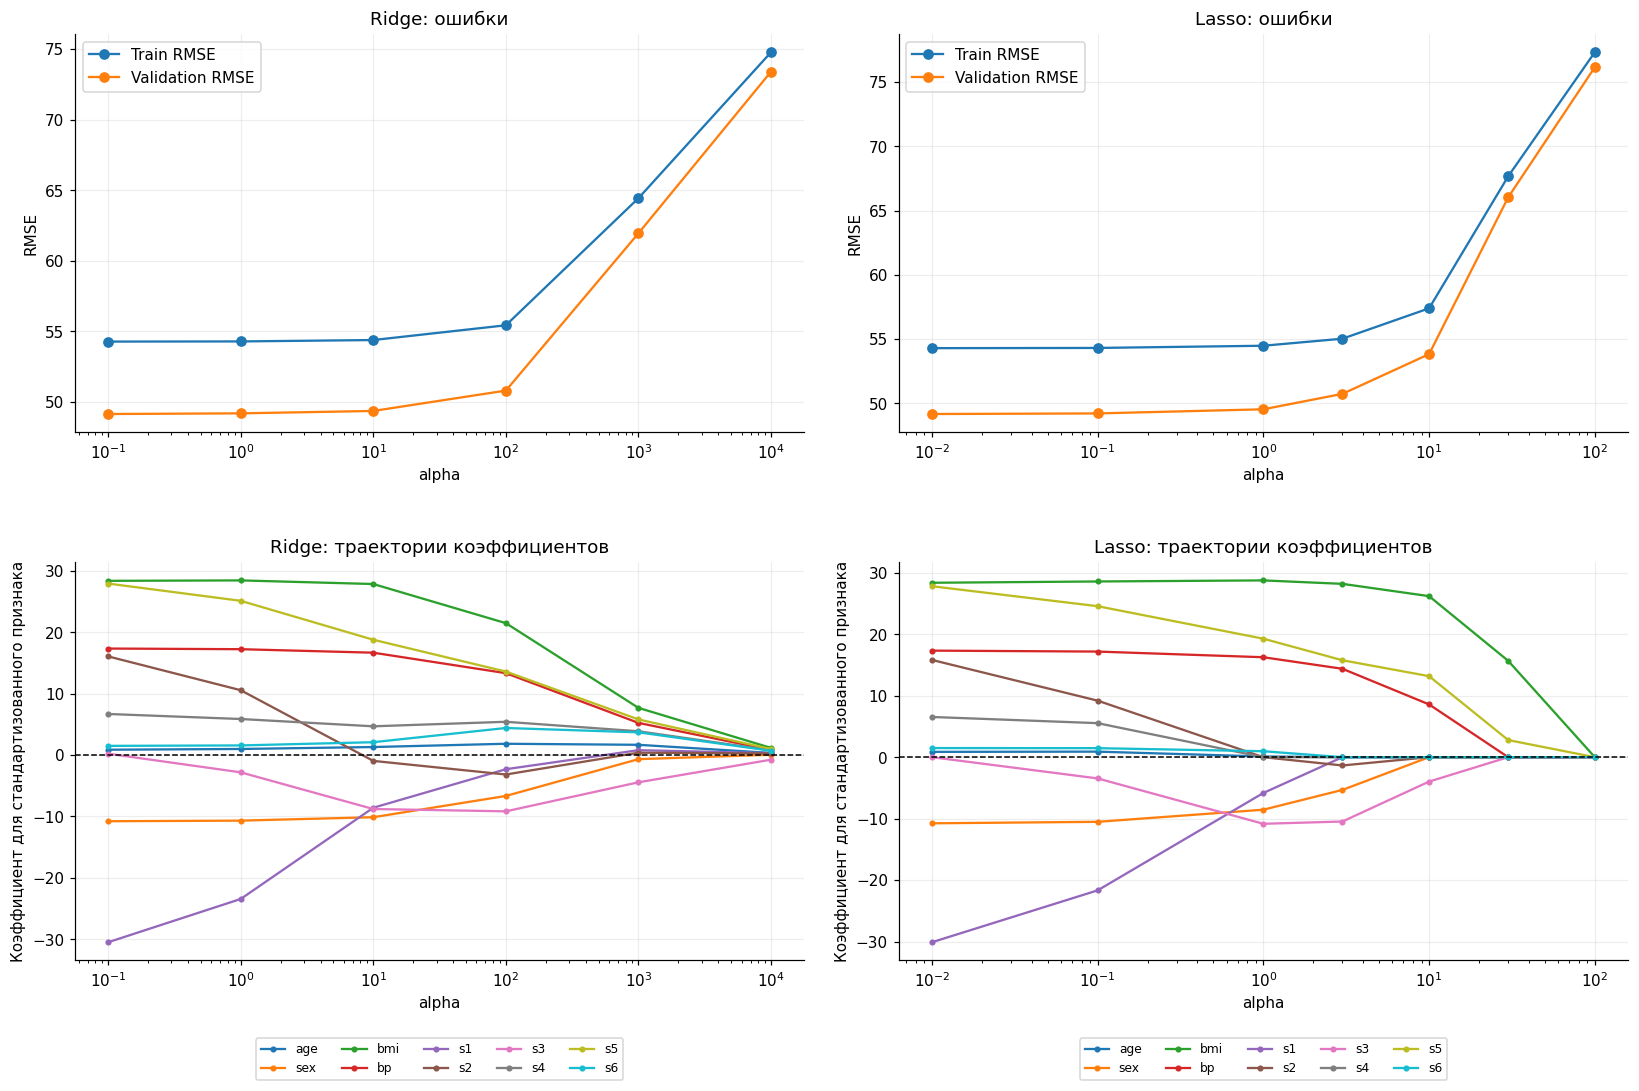

Ridge: признаки, чей коэффициент хотя бы раз вырос: ['age', 'bmi', 's2', 's3', 's4', 's6']
Lasso alpha=1: {'age': np.float64(0.112), 'sex': np.float64(-8.545), 'bmi': np.float64(28.764), 'bp': np.float64(16.263), 's1': np.float64(-5.822), 's2': np.float64(-0.0), 's3': np.float64(-10.836), 's4': np.float64(0.0), 's5': np.float64(19.278), 's6': np.float64(0.97)}


In [13]:
reg_ridge_alphas = [0.1, 1, 10, 100, 1000, 10000]
reg_lasso_alphas = [0.01, 0.1, 1, 3, 10, 30, 100]
reg_paths = {}
reg_path_rows = []
for family, alphas in [("Ridge", reg_ridge_alphas), ("Lasso", reg_lasso_alphas)]:
    for alpha in alphas:
        estimator = (reg_Ridge(alpha=alpha) if family == "Ridge"
                     else reg_Lasso(alpha=alpha, max_iter=20000))
        model = reg_Pipeline([
            ("scaler", reg_StandardScaler()), ("model", estimator),
        ]).fit(reg_X_train, reg_y_train)
        coefs = model.named_steps["model"].coef_.copy()
        reg_paths[(family, alpha)] = {"model": model, "coefs": coefs}
        reg_path_rows.append({"Метод": family, "alpha": alpha,
                              "Train RMSE": reg_rmse(reg_y_train, model.predict(reg_X_train)),
                              "Validation RMSE": reg_rmse(reg_y_valid, model.predict(reg_X_valid)),
                              "||w||_2": np.linalg.norm(coefs),
                              "Нулевых коэффициентов": int(np.count_nonzero(np.isclose(coefs, 0, atol=1e-9)))})
reg_path_table = pd.DataFrame(reg_path_rows)
display(reg_path_table.round(3))

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for column, (family, alphas) in enumerate([("Ridge", reg_ridge_alphas), ("Lasso", reg_lasso_alphas)]):
    df = reg_path_table.loc[reg_path_table["Метод"] == family]
    ax_err, ax_coef = axs[0, column], axs[1, column]
    ax_err.plot(df["alpha"], df["Train RMSE"], marker="o", label="Train RMSE")
    ax_err.plot(df["alpha"], df["Validation RMSE"], marker="o", label="Validation RMSE")
    ax_err.set(xscale="log", xlabel="alpha", ylabel="RMSE", title=f"{family}: ошибки")
    ax_err.legend()
    mat = np.stack([reg_paths[(family, a)]["coefs"] for a in alphas])
    for j, feature in enumerate(reg_X_train.columns):
        ax_coef.plot(alphas, mat[:, j], marker=".", label=feature)
    ax_coef.axhline(0, color="black", linestyle="--", linewidth=1)
    ax_coef.set(xscale="log", xlabel="alpha", ylabel="Коэффициент для стандартизованного признака",
                title=f"{family}: траектории коэффициентов")
    ax_coef.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=8)
fig.tight_layout(h_pad=3.7, w_pad=2)
plt.show()

reg_ridge_coef = np.stack([reg_paths[("Ridge", a)]["coefs"] for a in reg_ridge_alphas])
reg_ridge_growing = [feature for j, feature in enumerate(reg_X_train.columns)
                     if np.any(np.diff(np.abs(reg_ridge_coef[:, j])) > 1e-8)]
print("Ridge: признаки, чей коэффициент хотя бы раз вырос:", reg_ridge_growing)
print("Lasso alpha=1:", dict(zip(reg_X_train.columns,
                               np.round(reg_paths[("Lasso", 1)]["coefs"], 3))))


Train RMSE при росте `alpha` не уменьшается: модель всё сильнее ограничена штрафом. Validation RMSE здесь тоже в основном растёт: для этого разбиения самые слабые штрафы дают RMSE около 49.16, а сильные явно недообучают. У Ridge общая норма коэффициентов снижается, но не каждый по отдельности: например, $|w_{age}|$ растёт примерно с 0.87 при `alpha=0.1` до 1.84 при `alpha=100`. Это не противоречит 1.2, где утверждение было только про общую норму. У Lasso при `alpha=1` зануляются `s2` и `s4`, а при `alpha=100` — все десять признаков.

В `sklearn` Ridge минимизирует $\|y-Xw\|_2^2+\alpha\|w\|_2^2$. После деления на $2n$ получаем $\lambda=\alpha/n$ из задачи 1. Lasso минимизирует $\|y-Xw\|_2^2/(2n)+\alpha\|w\|_1$, поэтому для неё $\lambda=\alpha$. Поэтому одинаковые числа `alpha` не задают одинаковую силу Ridge- и Lasso-штрафов.

У Lasso при `alpha=1` коэффициент `bmi` около $+28.76$. Это условная связь, не причинный эффект. Даже после стандартизации $|w_j|$ нельзя считать универсальной мерой важности, поскольку коррелирующие признаки делят вклад, коэффициенты зависят от штрафа и состава признаков.


### 3.5

По результатам 3.2 и 3.4 выберите OLS или одну из моделей Ridge/Lasso
со `StandardScaler`. Зафиксируйте и обоснуйте выбор до обращения к test.

Вычислите test RMSE выбранной обученной модели. Постройте график фактических
значений против прогнозов с диагональю либо остатков против прогнозов с линией нуля.

Интерпретируйте график и укажите ограничение модели или проведённого эксперимента.

,Модель,Validation RMSE
0,OLS + StandardScaler,49.1497
1,Ridge alpha=0.1,49.1556
2,Lasso alpha=0.01,49.1575


Выбор до test: OLS + StandardScaler
Test RMSE: 56.970


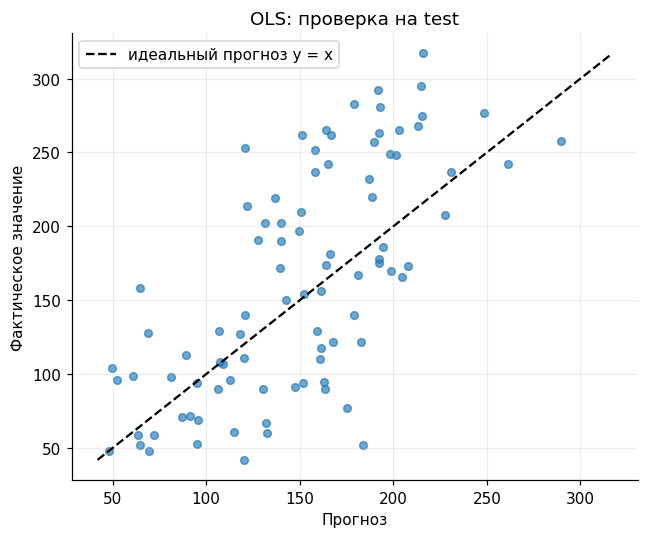

In [15]:
reg_candidates = [{"Модель": "OLS + StandardScaler", "Validation RMSE": reg_rmse(reg_y_valid, reg_ols.predict(reg_X_valid))}]
reg_candidates += [
    {"Модель": f"{family} alpha={a}", "Validation RMSE": row["Validation RMSE"]}
    for family, a in [("Ridge", 0.1), ("Lasso", 0.01)]
    for _, row in reg_path_table.loc[(reg_path_table["Метод"] == family) &
                                     (reg_path_table["alpha"] == a)].iterrows()
]
display(pd.DataFrame(reg_candidates).round(4))
reg_final_name = "OLS + StandardScaler"
reg_final_model = reg_ols
print("Выбор до test:", reg_final_name)

reg_test_predictions = reg_final_model.predict(reg_X_test)
reg_test_rmse = reg_rmse(reg_y_test, reg_test_predictions)
print(f"Test RMSE: {reg_test_rmse:.3f}")
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(reg_test_predictions, reg_y_test, alpha=0.65, s=25)
lims = [min(reg_test_predictions.min(), reg_y_test.min()),
        max(reg_test_predictions.max(), reg_y_test.max())]
ax.plot(lims, lims, "k--", label="идеальный прогноз y = x")
ax.set(xlabel="Прогноз", ylabel="Фактическое значение", title="OLS: проверка на test")
ax.legend()
fig.tight_layout()
plt.show()


На validation OLS ($49.15$) немного обошла Ridge (`alpha=0.1`: $49.16$) и Lasso (`alpha=0.01`: $49.16$), поэтому я выбрал OLS. На test RMSE получилась $56.97$ — выше, чем на validation ($49.15$). На графике точки могут сильно расходиться с диагональю, то есть линейная модель не всё объясняет.


## Задача 4. Классификация

Используйте набор Wisconsin Diagnostic Breast Cancer. Он содержит 30 числовых
характеристик клеточных ядер. Во всех пунктах используйте только `mean radius`
и `mean texture`. Целевая переменная перекодирована:
`1 = malignant` (злокачественная опухоль), `0 = benign` (доброкачественная опухоль).

Рассматриваются четыре метода:

- логистическая регрессия — модель вероятности класса с сигмоидой от линейной комбинации признаков;
- kNN — классификация по меткам ближайших соседей;
- SVM с RBF-ядром — метод опорных векторов с гауссовым ядром;
- дерево решений — последовательность разбиений по значениям признаков.

Стратифицированное разбиение train / validation / test — 60 / 20 / 20%.
Финальная оценка на test выполняется в пункте 4.5.

[Описание данных](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).

In [16]:
from IPython.display import Markdown as cls_Markdown
from sklearn.datasets import load_breast_cancer as cls_load_data
from sklearn.dummy import DummyClassifier as cls_DummyClassifier
from sklearn.linear_model import LogisticRegression as cls_LogisticRegression
from sklearn.neighbors import KNeighborsClassifier as cls_KNeighborsClassifier
from sklearn.svm import SVC as cls_SVC
from sklearn.tree import DecisionTreeClassifier as cls_DecisionTreeClassifier
from sklearn.pipeline import Pipeline as cls_Pipeline
from sklearn.preprocessing import StandardScaler as cls_StandardScaler
from sklearn.model_selection import train_test_split as cls_train_test_split
from sklearn.metrics import (
    balanced_accuracy_score as cls_balanced_accuracy_score,
    precision_score as cls_precision_score,
    recall_score as cls_recall_score,
    confusion_matrix as cls_confusion_matrix,
    ConfusionMatrixDisplay as cls_ConfusionMatrixDisplay,
)

cls_data = cls_load_data(as_frame=True)
cls_features = ["mean radius", "mean texture"]
cls_X = cls_data.data[cls_features].copy()
cls_y = (cls_data.target == 0).astype(int).rename("malignant")
cls_X_dev, cls_X_test, cls_y_dev, cls_y_test = cls_train_test_split(
    cls_X, cls_y, test_size=0.20, stratify=cls_y, random_state=SEED
)
cls_X_train, cls_X_val, cls_y_train, cls_y_val = cls_train_test_split(
    cls_X_dev, cls_y_dev, test_size=0.25, stratify=cls_y_dev, random_state=SEED
)
assert set(cls_X_train.index).isdisjoint(cls_X_val.index)
assert set(cls_X_train.index).isdisjoint(cls_X_test.index)
assert set(cls_X_val.index).isdisjoint(cls_X_test.index)
print("Число объектов train / validation / test:",
      len(cls_X_train), len(cls_X_val), len(cls_X_test))

Число объектов train / validation / test: 341 114 114


Функция `cls_plot_boundaries(models, titles=None, radius_multipliers=None, mark_errors=True)`
принимает словарь «название → обученная модель» и строит области предсказанных классов.
На графике отображаются train-объекты и, при `mark_errors=True`, ошибки validation.
`titles` задаёт подписи, `radius_multipliers` — множители радиуса на входе каждой модели.
Координаты графика соответствуют исходным единицам признаков.

In [19]:
cls_colors = {0: "#2a788e", 1: "#c95a47"}
cls_names = {0: "benign (0)", 1: "malignant (1)"}
cls_low = cls_X_train.min() - 0.06 * (cls_X_train.max() - cls_X_train.min())
cls_high = cls_X_train.max() + 0.06 * (cls_X_train.max() - cls_X_train.min())
cls_xx, cls_yy = np.meshgrid(
    np.linspace(cls_low.iloc[0], cls_high.iloc[0], 180),
    np.linspace(cls_low.iloc[1], cls_high.iloc[1], 180),
)
cls_grid = pd.DataFrame({cls_features[0]: cls_xx.ravel(), cls_features[1]: cls_yy.ravel()})

def cls_draw_boundary(model, ax, title, radius_multiplier=1, mark_errors=True):
    grid = cls_grid.copy()
    grid[cls_features[0]] *= radius_multiplier
    pred = model.predict(grid).reshape(cls_xx.shape)
    ax.contourf(cls_xx, cls_yy, pred, levels=[-0.5, 0.5, 1.5],
                colors=[cls_colors[0], cls_colors[1]], alpha=0.19)
    if hasattr(model, "decision_function"):
        score = model.decision_function(grid).reshape(cls_xx.shape)
        ax.contour(cls_xx, cls_yy, score, levels=[0], colors="#333333", linewidths=1)
    else:
        ax.contour(cls_xx, cls_yy, pred, levels=[0.5], colors="#333333", linewidths=1)
    for label in [0, 1]:
        mask = cls_y_train == label
        ax.scatter(cls_X_train.loc[mask, cls_features[0]],
                   cls_X_train.loc[mask, cls_features[1]],
                   color=cls_colors[label], s=15, alpha=0.65, label=cls_names[label])
    if mark_errors:
        val = cls_X_val.copy()
        val[cls_features[0]] *= radius_multiplier
        wrong = model.predict(val) != cls_y_val
        ax.scatter(cls_X_val.loc[wrong, cls_features[0]], cls_X_val.loc[wrong, cls_features[1]],
                   color="black", marker="x", s=30, linewidths=1, label="ошибка validation")
    ax.set(xlabel=cls_features[0], ylabel=cls_features[1], title=title,
           xlim=(cls_low.iloc[0], cls_high.iloc[0]),
           ylim=(cls_low.iloc[1], cls_high.iloc[1]))


def cls_plot_boundaries(models, titles=None, radius_multipliers=None, mark_errors=True):
    # models: словарь «название → обученная модель»; функция ничего не обучает.
    if not 1 <= len(models) <= 4:
        raise ValueError("Передайте от одной до четырёх обученных моделей")
    titles = {} if titles is None else titles
    radius_multipliers = {} if radius_multipliers is None else radius_multipliers
    columns = min(2, len(models))
    rows = (len(models) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(5.5 * columns, 4 * rows),
                             sharex=True, sharey=True, squeeze=False)
    for ax, (name, model) in zip(axes.flat, models.items()):
        cls_draw_boundary(model, ax, titles.get(name, name),
                          radius_multiplier=radius_multipliers.get(name, 1),
                          mark_errors=mark_errors)
    for ax in list(axes.flat)[len(models):]:
        ax.set_visible(False)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle("Точки — train" + ("; крестики — ошибки validation" if mark_errors else ""))
    fig.tight_layout()
    plt.show()

### 4.1

На train определите диапазоны двух признаков и доли классов.
Постройте диаграмму `mean radius` × `mean texture` с цветом по классу.

1. В каких областях ожидаете ошибки классификатора по этим двум признакам? Обоснуйте ответ.
2. Вычислите accuracy, recall класса 1 и balanced accuracy для правила «всегда класс большинства». Сравните информативность этих метрик.

В пунктах 4.2 и 4.5 основная метрика — balanced accuracy:
$\mathrm{BA}=(\mathrm{recall}_0+\mathrm{recall}_1)/2$.

,min,max
mean radius,6.981,27.42
mean texture,9.710,39.28


,Класс,Доля train
0,benign (0),0.628
1,malignant (1),0.372


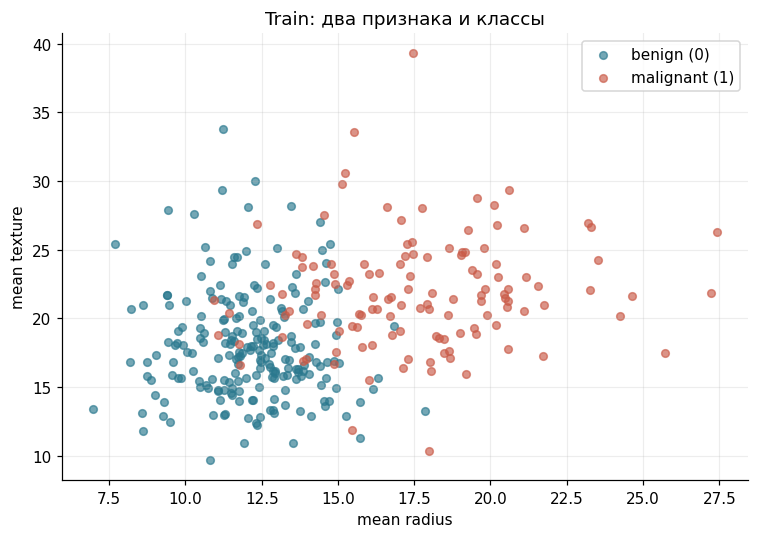

,Accuracy,Recall класса 1,Balanced accuracy
Класс большинства,0.623,0.0,0.5


In [21]:
cls_ranges = cls_X_train.agg(["min", "max"]).T
cls_share = cls_y_train.value_counts(normalize=True).sort_index()
display(cls_ranges.round(3))
display(pd.DataFrame({"Класс": [cls_names[k] for k in cls_share.index],
                      "Доля train": cls_share.values}).round(3))
fig, ax = plt.subplots(figsize=(7, 5))
for label in [0, 1]:
    mask = cls_y_train == label
    ax.scatter(cls_X_train.loc[mask, cls_features[0]],
               cls_X_train.loc[mask, cls_features[1]], s=25, alpha=0.65,
               color=cls_colors[label], label=cls_names[label])
ax.set(xlabel="mean radius", ylabel="mean texture", title="Train: два признака и классы")
ax.legend()
fig.tight_layout()
plt.show()

cls_dummy = cls_DummyClassifier(strategy="most_frequent").fit(cls_X_train, cls_y_train)
cls_dummy_val_pred = cls_dummy.predict(cls_X_val)
cls_dummy_val = {
    "Accuracy": float(np.mean(cls_dummy_val_pred == cls_y_val)),
    "Recall класса 1": cls_recall_score(cls_y_val, cls_dummy_val_pred, zero_division=0),
    "Balanced accuracy": cls_balanced_accuracy_score(cls_y_val, cls_dummy_val_pred),
}
display(pd.DataFrame([cls_dummy_val], index=["Класс большинства"]).round(3))


По диаграмме классы заметно перекрываются при средних радиусах примерно 12–17, поэтому там ожидаются ошибки. Большинство train — класс 0 (доброкачественный), около 63%. Dummy получает accuracy примерно 0.623 на validation, но recall злокачественного класса 1 равен нулю. Balanced accuracy равна 0.5 и сразу показывает, что модель распознаёт только один класс, а не оба.


### 4.2

Сравните логистическую регрессию, kNN, SVM с RBF-ядром и дерево решений.
Самостоятельно выберите гиперпараметры для исследования и подберите их значения
по validation balanced accuracy. Для каждого метода исследуйте не менее трёх
значений хотя бы одного гиперпараметра, определяющего сложность или структуру
модели. Сохраните выбранную модель и представьте результаты сравнения.

Постройте границы выбранных моделей. Можно использовать функцию
`cls_plot_boundaries(models)`, передав словарь обученных моделей.

Отдельно исследуйте влияние глубины дерева на train и validation balanced accuracy.
Диапазон глубин выберите самостоятельно и представьте результаты на графике.

1. Обоснуйте выбор настроек и объясните различия форм границ четырёх моделей.
2. Выберите одну область ошибок validation и объясните её через форму границы.
3. Интерпретируйте зависимости метрик от глубины дерева.

,Метод,Настройка,Train BA,Validation BA
0,Логистическая регрессия,C=0.01,0.8048,0.7604
1,Логистическая регрессия,C=0.1,0.8687,0.8439
2,Логистическая регрессия,C=1,0.8814,0.8601
3,Логистическая регрессия,C=10,0.8853,0.8601
4,Логистическая регрессия,C=100,0.8853,0.8531
5,kNN,k=1,1.0000,0.8038
6,kNN,k=3,0.9104,0.8485
7,kNN,k=5,0.8940,0.8323
8,kNN,k=9,0.8759,0.8788
9,kNN,k=15,0.8916,0.8718


,Метод,Настройка,Train BA,Validation BA
14,SVM RBF,C=1,0.8924,0.8788
8,kNN,k=9,0.8759,0.8788
17,Дерево,depth=1,0.8734,0.8651
2,Логистическая регрессия,C=1,0.8814,0.8601


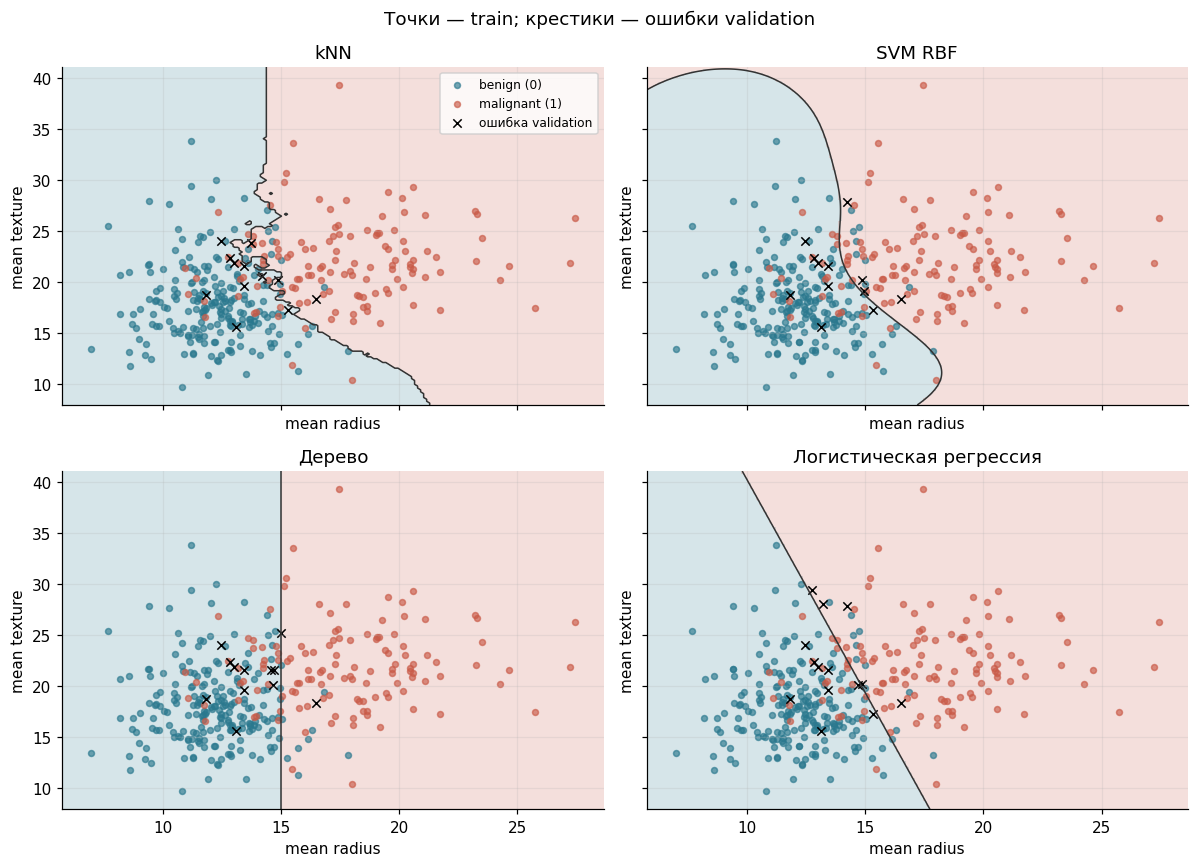

,Глубина,Train BA,Validation BA
0,1,0.8734,0.8651
1,2,0.8756,0.8418
2,3,0.8796,0.8534
3,4,0.9064,0.8207
4,5,0.9268,0.8066
5,6,0.9536,0.8390
6,7,0.9859,0.8203
7,8,0.9898,0.8203
8,9,0.9961,0.8320
9,10,1.0000,0.8203


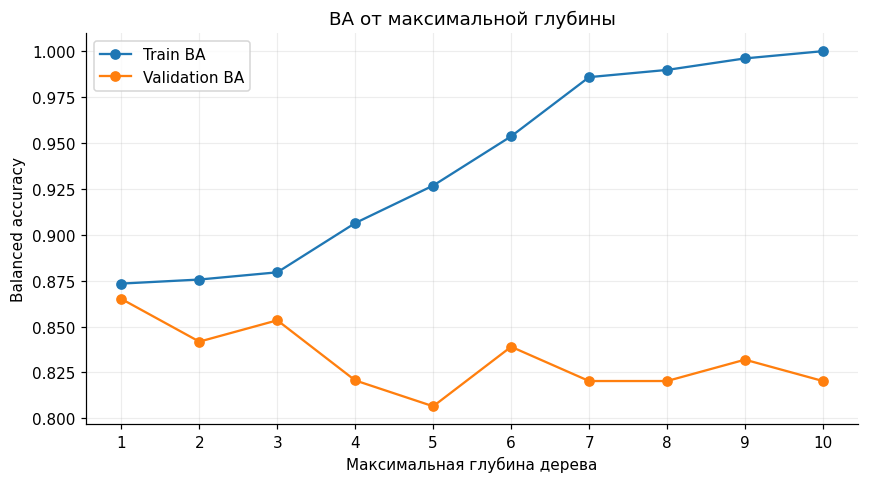

In [23]:
cls_grids = {
    "Логистическая регрессия": [(f"C={C}", cls_Pipeline([
        ("scaler", cls_StandardScaler()),
        ("model", cls_LogisticRegression(C=C, max_iter=2000, random_state=SEED)),
    ])) for C in [0.01, 0.1, 1, 10, 100]],
    "kNN": [(f"k={k}", cls_Pipeline([
        ("scaler", cls_StandardScaler()),
        ("model", cls_KNeighborsClassifier(n_neighbors=k)),
    ])) for k in [1, 3, 5, 9, 15, 25, 41]],
    "SVM RBF": [(f"C={C}", cls_Pipeline([
        ("scaler", cls_StandardScaler()),
        ("model", cls_SVC(kernel="rbf", C=C, gamma="scale")),
    ])) for C in [0.01, 0.1, 1, 10, 100]],
    "Дерево": [(f"depth={depth}", cls_DecisionTreeClassifier(max_depth=depth, random_state=SEED))
               for depth in [1, 2, 3, 4, 5, 6, 8, 10, None]],
}
cls_grid_rows = []
cls_grid_models = {}
for family, options in cls_grids.items():
    for setting, estimator in options:
        fitted = estimator.fit(cls_X_train, cls_y_train)
        cls_grid_models[(family, setting)] = fitted
        cls_grid_rows.append({"Метод": family, "Настройка": setting,
                              "Train BA": cls_balanced_accuracy_score(cls_y_train, fitted.predict(cls_X_train)),
                              "Validation BA": cls_balanced_accuracy_score(cls_y_val, fitted.predict(cls_X_val))})
cls_grid_table = pd.DataFrame(cls_grid_rows)
display(cls_grid_table.round(4))

cls_best_rows = (cls_grid_table.sort_values("Validation BA", ascending=False, kind="stable")
                 .drop_duplicates("Метод", keep="first"))
cls_chosen = {row["Метод"]: cls_grid_models[(row["Метод"], row["Настройка"])]
              for _, row in cls_best_rows.iterrows()}
display(cls_best_rows.sort_values("Метод").round(4))
cls_plot_boundaries(cls_chosen)

cls_tree_depths = list(range(1, 11))
cls_depth_rows = []
for depth in cls_tree_depths:
    model = cls_DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(cls_X_train, cls_y_train)
    cls_depth_rows.append({"Глубина": depth,
                           "Train BA": cls_balanced_accuracy_score(cls_y_train, model.predict(cls_X_train)),
                           "Validation BA": cls_balanced_accuracy_score(cls_y_val, model.predict(cls_X_val))})
cls_depth_table = pd.DataFrame(cls_depth_rows)
display(cls_depth_table.round(4))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cls_depth_table["Глубина"], cls_depth_table["Train BA"], marker="o", label="Train BA")
ax.plot(cls_depth_table["Глубина"], cls_depth_table["Validation BA"], marker="o", label="Validation BA")
ax.set(xlabel="Максимальная глубина дерева", ylabel="Balanced accuracy", xticks=cls_tree_depths,
       title="BA от максимальной глубины")
ax.legend()
fig.tight_layout()
plt.show()


Я менял `C` у логистической регрессии (сила регуляризации) и SVM (штраф за ошибки, простота границы), число соседей у kNN и глубину дерева; в каждой строке таблицы модель отдельно обучена на train. По validation выбраны логистическая регрессия `C=1` (BA $0.860$), kNN `k=9` ($0.879$), SVM `C=1` ($0.879$) и дерево глубины 1 ($0.865$). Логистическая регрессия даёт прямую границу, kNN - ломаная, RBF SVM - плавную изогнутую, дерево - вертикальные/горизонтальные участки. Поэтому в области перекрытия SVM и kNN лучше могут выделить какие то отдельные точки, а логистическая регрессия и дерево там ошибаются.

У дерева с ростом глубины train BA поднимается примерно с $0.873$ до $1.0$, но validation BA после глубины 1 в основном хуже и колеблется. То есть всё более подробные разбиения подстраиваются под train, а не гарантированно улучшают качество на новых объектах.


### 4.3

Создайте копии train и validation, умножив только `mean radius` на `100`.
На исходных и преобразованных данных обучите по одной версии:

- kNN с `n_neighbors=9` без стандартизации;
- kNN с `n_neighbors=9` и `StandardScaler`;
- дерева с `max_depth=3`, `random_state=SEED`.

Для каждого метода вычислите долю validation-объектов, у которых изменилась
предсказанная метка. Изобразите две границы kNN без стандартизации
в исходных координатах. При использовании `cls_plot_boundaries` передайте
`radius_multipliers={название_преобразованной_модели: 100}` и `mark_errors=False`.

Объясните результаты для каждого метода и роль масштаба признаков.

Ожидание: Изменение единиц радиуса повлияет на kNN без scaler, на kNN со scaler и дерево - нет.


,Метод,Изменённых меток,Доля изменённых меток,BA до,BA после
0,kNN без scaler,7,0.0614,0.8858,0.8510
1,kNN + scaler,0,0.0000,0.8788,0.8788
2,Дерево depth=3,0,0.0000,0.8534,0.8534


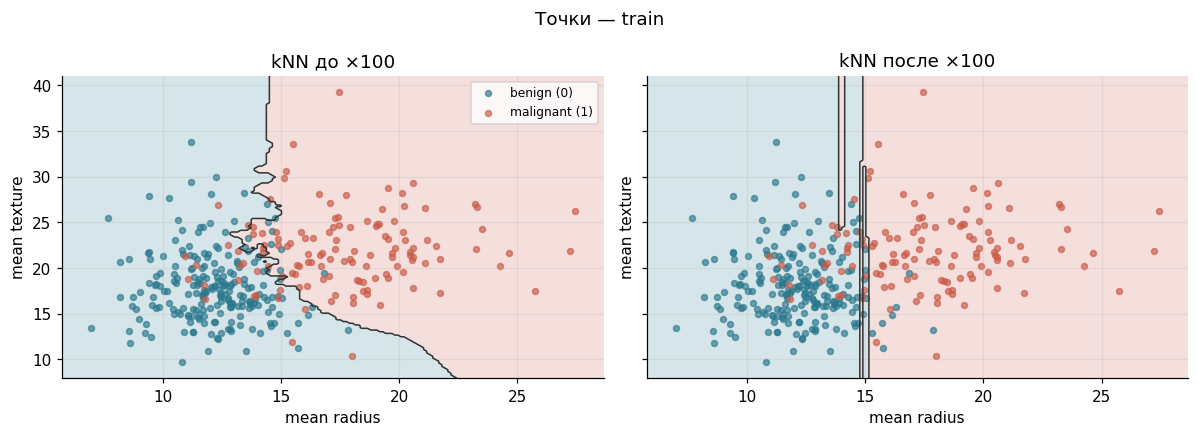

In [24]:
cls_X_train_100 = cls_X_train.copy()
cls_X_val_100 = cls_X_val.copy()
cls_X_train_100["mean radius"] *= 100
cls_X_val_100["mean radius"] *= 100
cls_scale_specs = {
    "kNN без scaler": cls_KNeighborsClassifier(n_neighbors=9),
    "kNN + scaler": cls_Pipeline([
        ("scaler", cls_StandardScaler()), ("model", cls_KNeighborsClassifier(n_neighbors=9)),
    ]),
    "Дерево depth=3": cls_DecisionTreeClassifier(max_depth=3, random_state=SEED),
}
cls_scale_models = {}
cls_scale_rows = []
for name, estimator in cls_scale_specs.items():
    original = clone(estimator).fit(cls_X_train, cls_y_train)
    changed = clone(estimator).fit(cls_X_train_100, cls_y_train)
    cls_scale_models[name] = (original, changed)
    p0 = original.predict(cls_X_val)
    p1 = changed.predict(cls_X_val_100)
    cls_scale_rows.append({"Метод": name, "Изменённых меток": int(np.sum(p0 != p1)),
                           "Доля изменённых меток": np.mean(p0 != p1),
                           "BA до": cls_balanced_accuracy_score(cls_y_val, p0),
                           "BA после": cls_balanced_accuracy_score(cls_y_val, p1)})
display(pd.DataFrame(cls_scale_rows).round(4))
cls_plot_boundaries(
    {"kNN до ×100": cls_scale_models["kNN без scaler"][0],
     "kNN после ×100": cls_scale_models["kNN без scaler"][1]},
    radius_multipliers={"kNN после ×100": 100}, mark_errors=False,
)


У kNN без scaler после умножения радиуса на 100 изменились 7 меток из 114 validation-объектов (около 6.1%), граница заметно изменилась. У kNN со scaler не изменилась ни одна метка, т.к. scaler компенсирует пересчёт единиц. У дерева 3 метки тоже не изменились.


### 4.4

Для обученной логистической регрессии из 4.2 получите оценки вероятности
класса 1 на validation. Для порога $t$ используйте правило $\hat y=1$ при $p(x)\ge t$.
Постройте зависимости precision и recall от порога на отрезке $[0,1]$.

Для порогов `0.2, 0.5, 0.8` составьте таблицу: precision, recall, FP, FN.
При отсутствии положительных предсказаний используйте `zero_division=0`.

1. Как зависят FP и FN от порога? Исследуйте монотонность precision и recall. Объясните смысл `zero_division=0`.
2. Какой из трёх порогов вы выберете, если пропуск класса 1 значительно дороже ложного срабатывания? Какие данные нужны для численного обоснования выбора?
3. Как изменение порога влияет на вероятностные оценки, ранжирование объектов и границу классификации?

Ожидание: Более высокий порог даст меньше FP, больше FN и меньший или равный recall; precision может колебаться.


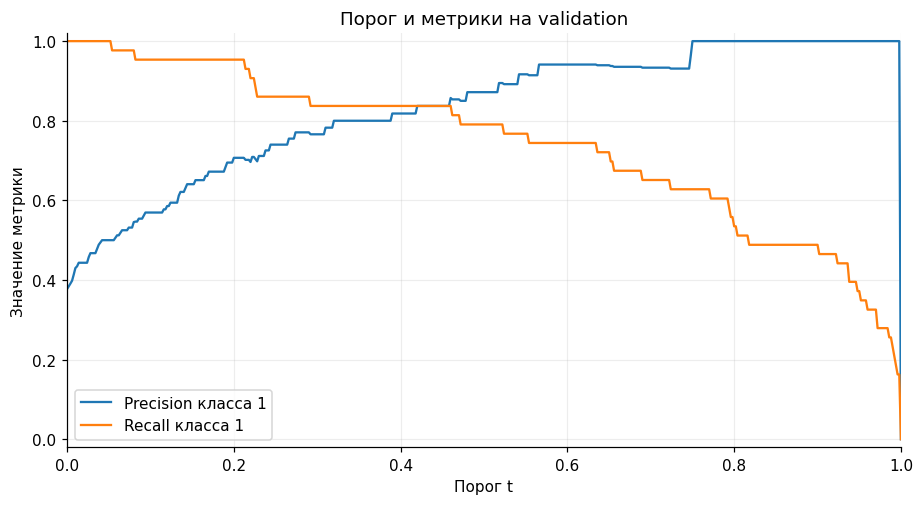

,Порог,Precision,Recall,FP,FN
0,0.2,0.7069,0.9535,17,2
1,0.5,0.8718,0.7907,5,9
2,0.8,1.0000,0.5349,0,20


In [25]:
cls_logit = cls_chosen["Логистическая регрессия"]
cls_val_proba = cls_logit.predict_proba(cls_X_val)[:, 1]
cls_thresholds = np.linspace(0, 1, 501)
cls_precision_curve = []
cls_recall_curve = []
for threshold in cls_thresholds:
    predictions = (cls_val_proba >= threshold).astype(int)
    cls_precision_curve.append(cls_precision_score(cls_y_val, predictions, zero_division=0))
    cls_recall_curve.append(cls_recall_score(cls_y_val, predictions, zero_division=0))
fig, ax = plt.subplots(figsize=(8.5, 4.7))
ax.plot(cls_thresholds, cls_precision_curve, label="Precision класса 1")
ax.plot(cls_thresholds, cls_recall_curve, label="Recall класса 1")
ax.set(xlabel="Порог t", ylabel="Значение метрики", xlim=(0, 1), ylim=(-0.02, 1.02),
       title="Порог и метрики на validation")
ax.legend()
fig.tight_layout()
plt.show()

cls_threshold_rows = []
for threshold in [0.2, 0.5, 0.8]:
    predictions = (cls_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = cls_confusion_matrix(cls_y_val, predictions, labels=[0, 1]).ravel()
    cls_threshold_rows.append({"Порог": threshold,
                               "Precision": cls_precision_score(cls_y_val, predictions, zero_division=0),
                               "Recall": cls_recall_score(cls_y_val, predictions, zero_division=0),
                               "FP": int(fp), "FN": int(fn)})
cls_threshold_table = pd.DataFrame(cls_threshold_rows)
display(cls_threshold_table.round(4))


При повышении порога с 0.2 до 0.8 FP падает с 17 до 0, а FN растёт с 2 до 20. Recall убывает. Precision на конкретной выборке вообще не обязана быть монотонной, хотя здесь на выбранных трёх порогах растёт.

Если пропустить злокачественный случай значительно дороже ложного срабатывания, то лучше брать $t=0.2$, т.к. пропусков здесь меньше всего, но ложных тревог больше. Для обоснованного численного выбора нужны стоимости FP и FN. Смена порога не меняет полученные моделью вероятности, но перемещает прямую границу решения в пространстве двух признаков.


### 4.5

По validation balanced accuracy выберите одну из четырёх моделей с подобранными
в пункте 4.2 гиперпараметрами. Зафиксируйте и обоснуйте выбор до обращения к test. Используйте обычный `predict`.

Оцените на test выбранную модель и `DummyClassifier(strategy="most_frequent")`,
обученный на train. Представьте balanced accuracy, precision и recall класса 1
в таблице и постройте матрицу ошибок выбранной модели.
Для precision используйте `zero_division=0`.

1. Какие ошибки преобладают? Как соотносятся матрица ошибок и рассчитанные метрики?
2. Сравните test и validation balanced accuracy. Интерпретируйте различие.

Зафиксировано до test: kNN k=9


,Метод,Настройка,Train BA,Validation BA
14,SVM RBF,C=1,0.8924,0.8788
8,kNN,k=9,0.8759,0.8788
17,Дерево,depth=1,0.8734,0.8651
2,Логистическая регрессия,C=1,0.8814,0.8601


,Модель,Test balanced accuracy,Test precision (1),Test recall (1)
0,kNN (k=9) + scaler,0.8621,0.9688,0.7381
1,Dummy: most frequent,0.5000,0.0000,0.0000


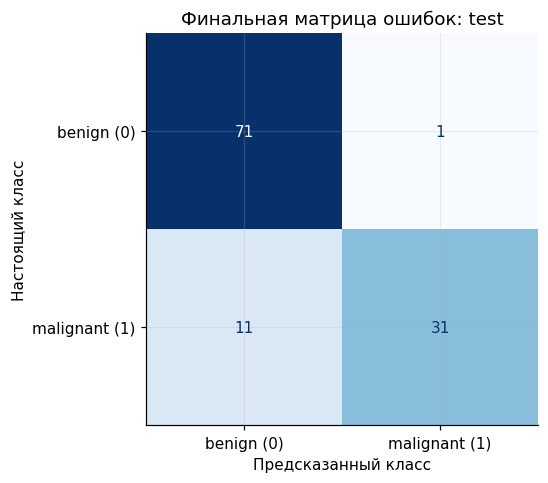

In [28]:
cls_final_name = "kNN"
cls_final_setting = "k=9"
assert cls_best_rows.loc[cls_best_rows["Метод"] == cls_final_name, "Настройка"].iloc[0] == cls_final_setting
cls_final_model = cls_chosen[cls_final_name]
print("Зафиксировано до test:", cls_final_name, cls_final_setting)
display(cls_best_rows.sort_values("Метод").round(4))

cls_test_pred = cls_final_model.predict(cls_X_test)
cls_dummy_test_pred = cls_dummy.predict(cls_X_test)
cls_test_table = pd.DataFrame([
    {"Модель": "kNN (k=9) + scaler",
     "Test balanced accuracy": cls_balanced_accuracy_score(cls_y_test, cls_test_pred),
     "Test precision (1)": cls_precision_score(cls_y_test, cls_test_pred, zero_division=0),
     "Test recall (1)": cls_recall_score(cls_y_test, cls_test_pred, zero_division=0)},
    {"Модель": "Dummy: most frequent",
     "Test balanced accuracy": cls_balanced_accuracy_score(cls_y_test, cls_dummy_test_pred),
     "Test precision (1)": cls_precision_score(cls_y_test, cls_dummy_test_pred, zero_division=0),
     "Test recall (1)": cls_recall_score(cls_y_test, cls_dummy_test_pred, zero_division=0)},
])
display(cls_test_table.round(4))
cls_test_cm = cls_confusion_matrix(cls_y_test, cls_test_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cls_ConfusionMatrixDisplay(cls_test_cm, display_labels=["benign (0)", "malignant (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set(title="Финальная матрица ошибок: test", xlabel="Предсказанный класс", ylabel="Настоящий класс")
fig.tight_layout()
plt.show()


Выбор зафиксирован по validation - kNN (`k=9`). На test BA составила $0.8621$ против $0.8788$ на validation. В матрице 11 ложноотрицательных (пропуск класса 1) и 1 ложноположительный, то есть здесь преобладают пропуски. Из 42 реальных объектов класса 1 найдены 31 - recall $31/42\approx0.7381$; среди 32 положительных прогнозов 31 верный - precision $31/32=0.96875$. Dummy имеет BA $0.5$ и recall класса 1, равный нулю.


## Выводы

Сформулируйте выводы по работе, укажите ограничения экспериментов
и предложите дальнейшее исследование.

В регрессии линейная модель заметно превзошла `DummyRegressor`, то есть признаки действительно содержат полезную информацию. Эксперименты с Ridge показали, что регуляризация зависит от масштаба признаков: без стандартизации изменение единиц измерения может менять результат модели. При увеличении `alpha` общая норма коэффициентов Ridge уменьшается, а Lasso дополнительно может занулять отдельные коэффициенты. При этом регуляризация не обязана улучшать качество на каждом конкретном разбиении: в нашем случае лучшую validation RMSE показала обычная линейная регрессия.

В классификации стало видно, что одной accuracy недостаточно при несбалансированных классах, поскольк модель, всегда предсказывающая класс большинства, имеет приемлемую accuracy, но не распознаёт класс 1. Поэтому для сравнения моделей использовалась balanced accuracy. Четыре алгоритма строят разные границы: логистическая регрессия - линейную, kNN - локальную ломаную, RBF-SVM - плавную нелинейную, а дерево - ступенчатую из прямоугольных областей. Увеличение глубины дерева улучшает качество на train, но может ухудшать validation из-за переобучения.

Также подтвердилось, что kNN чувствителен к масштабу признаков, а стандартизация делает его устойчивее к смене единиц измерения. В целом результаты показывают, что качество зависит не только от алгоритма, но и от предобработки, регуляризации, гиперпараметров, метрики и порога решения.

Ограничения: небольшие фиксированные выборки, только два признака в классификации, одна проверка train/validation/test и отсутствие сведений о реальных стоимостях ошибок. Дальше имеет смысл повторить сравнение на нескольких случайных разбиениях, оценить устойчивость результатов, а затем исследовать дополнительные признаки.

## Документация

- [Линейные модели](https://scikit-learn.org/stable/modules/linear_model.html).
- [Pipeline](https://scikit-learn.org/stable/modules/compose.html#pipeline).
- [Метод ближайших соседей](https://scikit-learn.org/stable/modules/neighbors.html).
- [Деревья решений](https://scikit-learn.org/stable/modules/tree.html).
- [Метрики](https://scikit-learn.org/stable/modules/model_evaluation.html).